In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from datasets import load_dataset
import ast


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_DA = df[df['job_title_short']  == 'Data Analyst'].copy()

c:\Phython\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df_DA['Job_Posted_Month_No'] = df['job_posted_date'].dt.month
df_DA_Exploaded = df_DA.explode('job_skills')
df_DA_Exploaded_Pivot = df_DA_Exploaded.pivot_table(index='Job_Posted_Month_No', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_Exploaded_Pivot.loc['Total'] = df_DA_Exploaded_Pivot.sum()
Data_Reset = df_DA_Exploaded_Pivot[df_DA_Exploaded_Pivot.loc['Total'].sort_values(ascending=False).index]
Data_Reset_Total = Data_Reset.drop('Total')
Data_Reset_Total_Reset = Data_Reset_Total.reset_index()
Data_Reset_Total_Reset['job_posted_month'] = Data_Reset_Total_Reset['Job_Posted_Month_No'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))


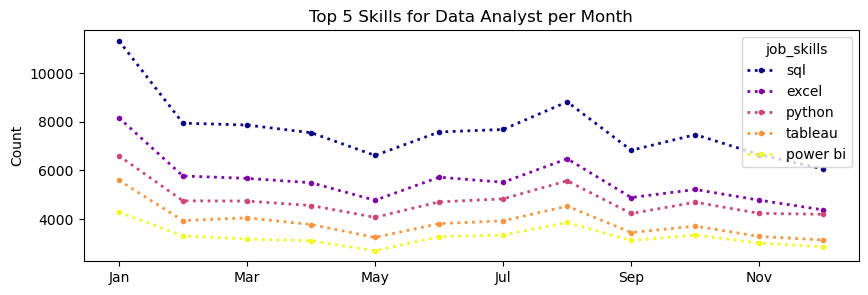

In [3]:
df_DA['Job_Posted_Month_No'] = df['job_posted_date'].dt.month
df_DA_Exploaded = df_DA.explode('job_skills')
df_DA_Exploaded_Pivot = df_DA_Exploaded.pivot_table(index='Job_Posted_Month_No', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_Exploaded_Pivot.loc['Total'] = df_DA_Exploaded_Pivot.sum()
Data_Reset = df_DA_Exploaded_Pivot[df_DA_Exploaded_Pivot.loc['Total'].sort_values(ascending=False).index]
Data_Reset_Total = Data_Reset.drop('Total')
Data_Reset_Total_Reset = Data_Reset_Total.reset_index()
Data_Reset_Total_Reset['Job_Posted_Month_No'] = pd.to_datetime(
    Data_Reset_Total_Reset['Job_Posted_Month_No'], format='%m'
).dt.strftime('%b')
Data_Reset_Total_Reset = Data_Reset_Total_Reset.set_index('Job_Posted_Month_No')
Data_Reset_Total_Reset.iloc[:, :5].plot(kind='line', linewidth=2, linestyle=':', colormap='plasma', marker='o', markersize=3, figsize=(10, 3))
plt.title('Top 5 Skills for Data Analyst per Month')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

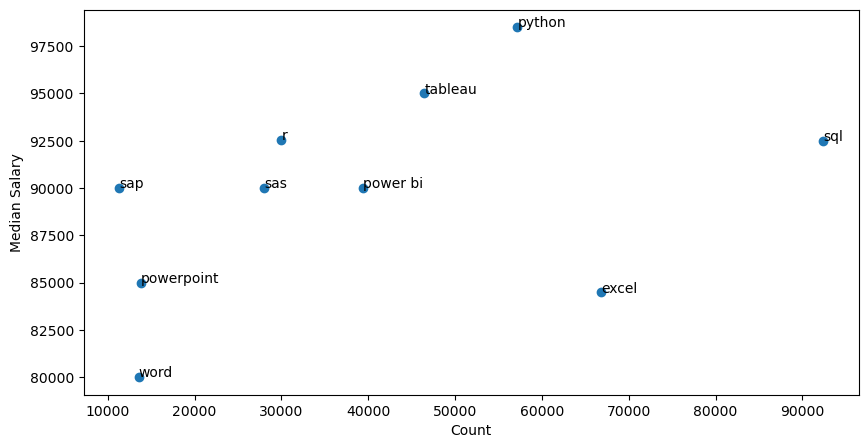

In [4]:
df_DA_Exploaded = df_DA.explode('job_skills')

Pivot_DA = df_DA_Exploaded.groupby('job_skills').agg(
    median=('salary_year_avg', 'median'),
    Count=('job_skills', 'count')
)

Pivot_DA = Pivot_DA.sort_values('Count', ascending=False).head(10)

# 🔴 IMPORTANT: create plot first
plt.figure(figsize=(10,5))
plt.scatter(Pivot_DA['Count'], Pivot_DA['median'])

for i, txt in enumerate(Pivot_DA.index):
    plt.text(Pivot_DA['Count'].iloc[i], Pivot_DA['median'].iloc[i], txt)

plt.xlabel("Count")
plt.ylabel("Median Salary")
plt.show()

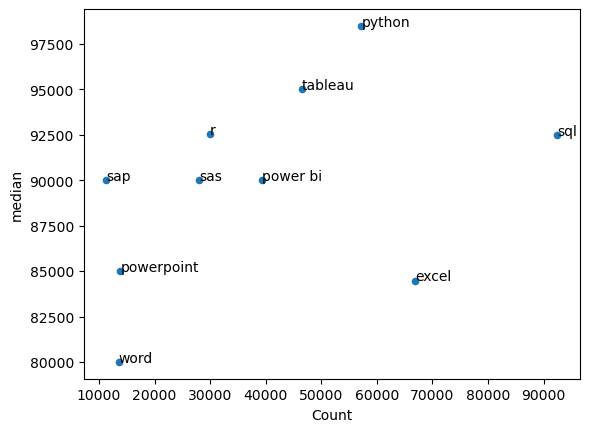

In [5]:
df_DA_Exploaded = df_DA.explode('job_skills')

Pivot_DA = df_DA_Exploaded.groupby('job_skills').agg(
    median=('salary_year_avg', 'median'),
    Count=('job_skills', 'count')
)

Pivot_DA = Pivot_DA.sort_values('Count', ascending=False).head(10)
Pivot_DA.plot(kind='scatter', x='Count', y='median')


for i, txt in enumerate(Pivot_DA.index):
    plt.text(Pivot_DA['Count'].iloc[i], Pivot_DA['median'].iloc[i], txt)
plt.show()

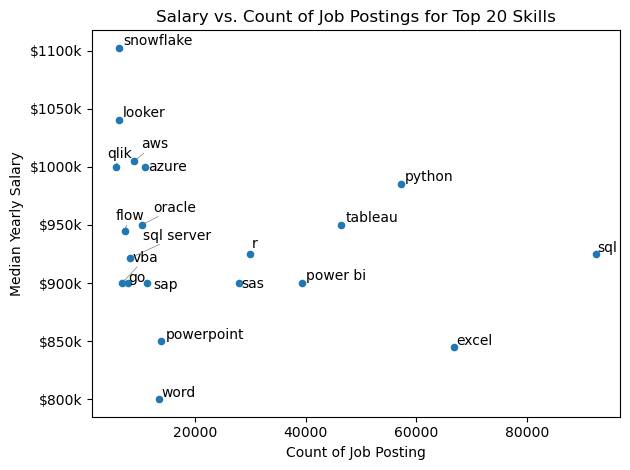

In [25]:
fig, ax= plt.subplots()

Pivot_DA = df_DA.explode('job_skills') 
Pivot_DA = df_DA_Exploaded.groupby('job_skills').agg(median = ('salary_year_avg', 'median'), Count = ('job_skills', 'count')) 


Pivot_DA = Pivot_DA.sort_values('Count', ascending=False).head(20) 
Pivot_DA.plot(kind='scatter', x='Count', y='median', ax=ax)

texts = []
for i, txt in enumerate(Pivot_DA.index): 
    texts.append(plt.text(Pivot_DA['Count'].iloc[i], Pivot_DA['median'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))


ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/100)}k'))

plt.xlabel('Count of Job Posting')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top 20 Skills')
plt.tight_layout()
plt.show()

In [ ]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [7]:
from adjustText import adjust_text